# UWB LOS/NLOS Classification & Distance Estimation — Machine Learning Models

**Course:** CSC3105 Data Analytics and AI  
**Dataset:** UWB-LOS-NLOS-Dataset (Decawave DWM1000, 42,000 samples, 7 indoor environments)  

---

## Overview

This notebook implements the full machine learning pipeline for the two tasks defined in the project brief:

| Task | Type | Target | Description |
|---|---|---|---|
| **Task 1** | Binary Classification | `NLOS` (0=LOS, 1=NLOS) | Identify whether a UWB signal path is Line-of-Sight or Non-Line-of-Sight |
| **Task 2** | Regression | `RANGE` (metres) | Estimate the measured range (distance) from signal features |

### Models Evaluated

**Classification:** Logistic Regression · Random Forest · XGBoost · Linear SVM · MLP · 1D CNN  
**Regression:** Random Forest · XGBoost · MLP

Each model section contains:
- Theoretical background and mathematical formulation
- Justification for why the model suits this problem
- Implementation and hyperparameter choices
- Performance evaluation with metrics and visualisations

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path
from scipy.stats import kurtosis, skew

# Sklearn — preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn — classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Sklearn — regressors
from sklearn.linear_model import Ridge

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost version:", xgb.__version__)
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not available — XGBoost sections will be skipped.")
    print("To fix on macOS: brew install libomp")

# TensorFlow / Keras (for 1D CNN)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception:
    TF_AVAILABLE = False
    print("TensorFlow not installed — 1D CNN section will be skipped.")

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
print("\nAll imports loaded.")


XGBoost version: 3.2.0
TensorFlow not installed — 1D CNN section will be skipped.

All imports loaded.


## 2. Data Loading

In [2]:
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"

all_files = sorted(DATASET_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files")

dataframes = []
for i, file in enumerate(all_files):
    df_temp = pd.read_csv(file)
    df_temp['dataset_part'] = file.stem
    dataframes.append(df_temp)
    print(f"  Loaded {i+1}/{len(all_files)}: {file.name} — {len(df_temp)} rows")

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"\nMerged dataset shape: {df_raw.shape}")
print(f"Classes: {df_raw['NLOS'].value_counts().to_dict()}")

Found 7 CSV files
  Loaded 1/7: uwb_dataset_part1.csv — 6000 rows
  Loaded 2/7: uwb_dataset_part2.csv — 6000 rows
  Loaded 3/7: uwb_dataset_part3.csv — 6000 rows
  Loaded 4/7: uwb_dataset_part4.csv — 6000 rows
  Loaded 5/7: uwb_dataset_part5.csv — 6000 rows
  Loaded 6/7: uwb_dataset_part6.csv — 6000 rows
  Loaded 7/7: uwb_dataset_part7.csv — 6000 rows

Merged dataset shape: (42000, 1032)
Classes: {0.0: 21000, 1.0: 21000}


## 3. Data Preprocessing

### 3.1 Theory

Preprocessing is a critical step in any machine learning pipeline. The EDA revealed several properties of this dataset that directly inform preprocessing decisions:

#### 3.1.1 Removing Zero-Variance Features

Three features — **CH**, **BITRATE**, and **PRFR** — have a standard deviation of exactly zero across all 42,000 samples. This means they carry no discriminative information whatsoever. Including them would add computational cost without any benefit, and some models (e.g., SVM, logistic regression) can behave poorly with constant features due to undefined normalisation.

**Decision:** Drop `CH`, `BITRATE`, `PRFR`, and `dataset_part`.

#### 3.1.2 CIR Dimensionality Reduction via Statistical Feature Extraction

The raw CIR waveform contains **1,016 time-domain samples** per measurement. Using all 1,016 values directly as input features for tree-based models creates:
- **Curse of dimensionality**: with ~1,030 features and 42,000 samples, the feature-to-sample ratio is adequate, but many CIR samples are correlated
- **Redundancy**: adjacent CIR samples are highly correlated in time
- **Training cost**: training XGBoost or SVM on 1,030-dimensional inputs is computationally expensive

**Solution:** Extract 8 statistical descriptors from the CIR waveform per sample, reducing 1,016 features to 8:

| Feature | Formula | Physical Meaning |
|---|---|---|
| `cir_mean` | $\mu = \frac{1}{N}\sum x_i$ | Average signal amplitude |
| `cir_std` | $\sigma = \sqrt{\frac{1}{N}\sum(x_i - \mu)^2}$ | Signal variability |
| `cir_max` | $\max(x_i)$ | Peak amplitude |
| `cir_peak_idx` | $\arg\max(x_i)$ | Location of the dominant path |
| `cir_energy` | $E = \sum x_i^2$ | Total signal energy |
| `cir_kurtosis` | $\kappa = \frac{E[(x-\mu)^4]}{\sigma^4}$ | Peak sharpness (LOS signals have sharper peaks → higher kurtosis) |
| `cir_skewness` | $\gamma = \frac{E[(x-\mu)^3]}{\sigma^3}$ | Waveform asymmetry |
| `cir_rms` | $\text{RMS} = \sqrt{\frac{1}{N}\sum x_i^2}$ | Root mean square power |

**Theoretical justification for kurtosis:** In LOS conditions, the CIR exhibits a sharp, concentrated peak at the first arriving path. This produces a high kurtosis value (leptokurtic distribution). In NLOS conditions, energy is spread across multiple delayed paths due to reflections, resulting in a flatter, lower-kurtosis distribution. This property has been exploited in published UWB NLOS identification literature (Maranò et al., 2010; Güvenç & Chong, 2009).

#### 3.1.3 Feature Scaling

Features in this dataset span very different numerical ranges:
- `FP_AMP1` ranges up to ~20,000
- `STDEV_NOISE` ranges from 28 to 324
- `FP_IDX` ranges from 707 to 848

Distance-based and gradient-descent-based models (SVM, Logistic Regression, MLP, CNN) are sensitive to feature scale. **StandardScaler** transforms each feature to zero mean and unit variance:

$$x' = \frac{x - \mu}{\sigma}$$

Tree-based models (Random Forest, XGBoost) are invariant to monotonic feature transformations and do not require scaling, but applying it causes no harm.

#### 3.1.4 Train/Test Split

An **80:20 stratified split** is used:
- **80% training** (33,600 samples): sufficient data for all models to learn signal patterns across all 7 environments
- **20% test** (8,400 samples): held-out set for unbiased final evaluation
- **Stratified**: ensures both splits maintain the 50:50 LOS/NLOS balance, preventing evaluation bias

In [3]:
# ── Column definitions ────────────────────────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'
DROP_COLS    = ['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

CIR_COLS = [c for c in df_raw.columns if c.startswith('CIR')]
print(f"Metadata features : {len(METADATA_FEATURES)}")
print(f"CIR columns       : {len(CIR_COLS)}")

Metadata features : 11
CIR columns       : 1017


In [4]:
# ── CIR statistical feature extraction ───────────────────────────────────────
print("Extracting CIR statistical features (this may take ~30 seconds)...")

cir_matrix = df_raw[CIR_COLS].values.astype(np.float32)

cir_stats = pd.DataFrame({
    'cir_mean'      : np.mean(cir_matrix, axis=1),
    'cir_std'       : np.std(cir_matrix, axis=1),
    'cir_max'       : np.max(cir_matrix, axis=1),
    'cir_peak_idx'  : np.argmax(cir_matrix, axis=1).astype(float),
    'cir_energy'    : np.sum(cir_matrix ** 2, axis=1),
    'cir_kurtosis'  : kurtosis(cir_matrix, axis=1),
    'cir_skewness'  : skew(cir_matrix, axis=1),
    'cir_rms'       : np.sqrt(np.mean(cir_matrix ** 2, axis=1)),
})

print(f"CIR statistical features shape: {cir_stats.shape}")
cir_stats.describe().round(2)

Extracting CIR statistical features (this may take ~30 seconds)...
CIR statistical features shape: (42000, 8)


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms
count,42000.00,42000.00,42000.00,42000.00,4.200000e+04,42000.00,42000.00,42000.00
mean,425.15,1111.88,15969.11,710.28,1.562511e+09,102.78,9.17,1196.53
std,94.53,332.31,4749.30,171.47,7.847356e+08,42.45,2.00,323.59
min,186.08,78.18,431.00,0.00,4.594340e+07,-1.15,-0.49,212.55
25%,360.05,937.49,14091.50,748.00,1.055141e+09,69.72,7.70,1018.58
50%,402.09,1160.75,17063.00,751.00,1.534104e+09,97.60,9.13,1228.19
75%,466.95,1317.15,18860.25,753.00,1.965904e+09,131.10,10.65,1390.34
max,1068.05,2440.98,37208.00,951.00,6.669654e+09,301.32,16.02,2560.89


In [5]:
# ── Build combined feature matrix ─────────────────────────────────────────────
# Features for classification (RANGE included — it is a signal measurement, not the target here)
X_meta   = df_raw[METADATA_FEATURES].values
X_cir_s  = cir_stats.values
X_all    = np.hstack([X_meta, X_cir_s])             # shape: (42000, 19)

# Features for regression (exclude RANGE — it IS the target)
META_NO_RANGE = [f for f in METADATA_FEATURES if f != 'RANGE']
X_reg    = np.hstack([df_raw[META_NO_RANGE].values, X_cir_s])  # shape: (42000, 18)

y_class  = df_raw[TARGET_CLASS].values.astype(int)
y_reg    = df_raw[TARGET_REG].values.astype(np.float32)

FEATURE_NAMES = METADATA_FEATURES + list(cir_stats.columns)

print(f"Classification feature matrix : {X_all.shape}")
print(f"Regression feature matrix     : {X_reg.shape}")
print(f"Class target distribution     : LOS={np.sum(y_class==0)}, NLOS={np.sum(y_class==1)}")

Classification feature matrix : (42000, 19)
Regression feature matrix     : (42000, 18)
Class target distribution     : LOS=21000, NLOS=21000


In [6]:
# ── Train / Test split (80:20 stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_train)
X_te_sc    = scaler.transform(X_test)

scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train LOS/NLOS : {np.sum(y_train==0)} / {np.sum(y_train==1)}")
print(f"Test  LOS/NLOS : {np.sum(y_test==0)} / {np.sum(y_test==1)}")

Training set   : 33600 samples
Test set       : 8400 samples
Train LOS/NLOS : 16800 / 16800
Test  LOS/NLOS : 4200 / 4200


## 4. Feature Importance Analysis

Before training all models, a preliminary Random Forest is used purely for **feature importance ranking**. Random Forest computes feature importance as the mean decrease in impurity (MDI) — the total reduction in the Gini impurity criterion contributed by each feature across all trees:

$$\text{Importance}(f) = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in N_t} \mathbb{1}[f_n = f] \cdot \Delta I(n)$$

where $T$ is the number of trees, $N_t$ are nodes in tree $t$, and $\Delta I(n)$ is the impurity reduction at node $n$.

This satisfies the project brief requirement to **rank features by importance** (Section a.V). The ranking also validates the EDA correlation findings.

In [7]:
print("Computing feature importance (Random Forest, 100 trees)...")
rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Computing feature importance (Random Forest, 100 trees)...

Top 15 most important features:
     feature  importance
      RXPACC    0.265888
       RANGE    0.104406
     cir_max    0.100408
     FP_AMP3    0.068691
     CIR_PWR    0.063176
     cir_std    0.054773
   MAX_NOISE    0.051060
     FP_AMP2    0.046816
  cir_energy    0.037543
    cir_mean    0.033542
     FP_AMP1    0.032565
 STDEV_NOISE    0.031589
cir_skewness    0.028700
     cir_rms    0.026751
cir_kurtosis    0.024481


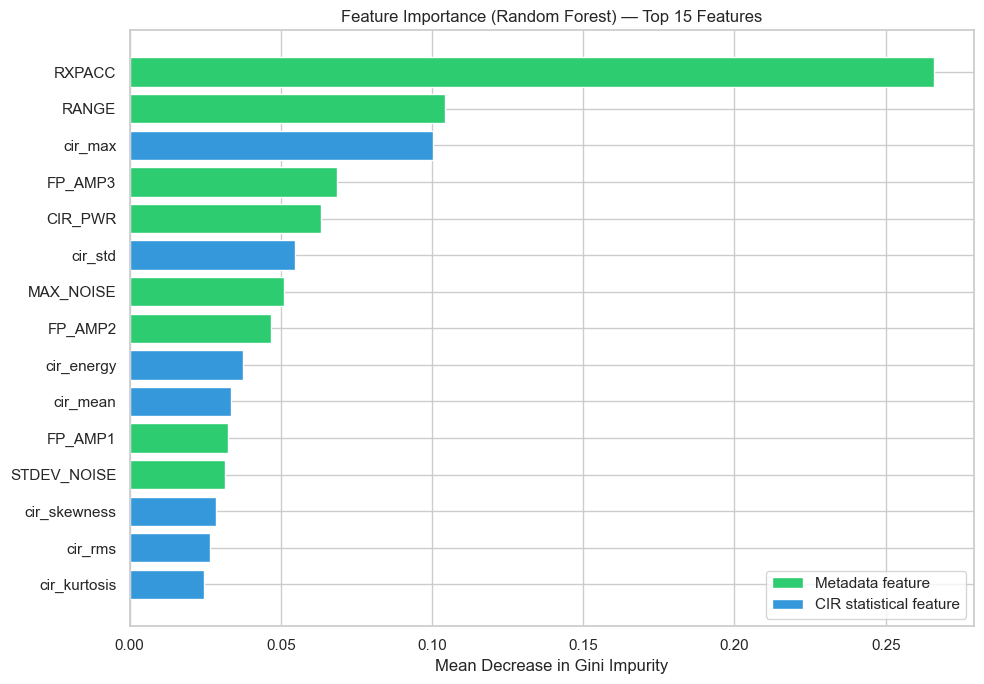


Interpretation: Features with higher importance contribute more to
separating LOS from NLOS. This confirms EDA correlation findings.


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
colors = ['#2ecc71' if 'cir' not in f else '#3498db' for f in top15['feature']]
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Feature Importance (Random Forest) — Top 15 Features')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Metadata feature'),
    Patch(facecolor='#3498db', label='CIR statistical feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print("\nInterpretation: Features with higher importance contribute more to")
print("separating LOS from NLOS. This confirms EDA correlation findings.")

## 5. Results Storage

A shared dictionary collects all model results for the final comparison.

In [9]:
# Dictionaries to collect results across models
clf_results  = {}   # classification: {model_name: {accuracy, f1, auc, ...}}
reg_results  = {}   # regression:     {model_name: {rmse, mae, r2}}
roc_data     = {}   # {model_name: (fpr, tpr, auc)} for ROC overlay plot
trained_clfs = {}   # store trained classifiers for confusion matrix plots

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit, predict, and store classification metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if proba and hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = None

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_score) if y_score is not None else float('nan')

    clf_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs[name] = (model, y_pred)

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_te, y_score)
        roc_data[name] = (fpr, tpr, auc)

    print(f"  {name:<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return model

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, and store regression metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f"  {name:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return model, y_pred

print("Helper functions ready.")

Helper functions ready.


---
# TASK 1 — LOS / NLOS Classification

---

## 6. Logistic Regression (Baseline)

### Theory

Logistic Regression is a **linear probabilistic classifier** that models the probability of class membership using the sigmoid function applied to a linear combination of input features:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

The model is trained by maximising the log-likelihood (equivalently, minimising cross-entropy loss) with L2 regularisation:

$$\mathcal{L} = -\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right] + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

### Why use it here?

Logistic Regression serves as the **baseline model**. Its purpose is to establish a performance floor. If nonlinear models (RF, XGBoost, MLP) cannot significantly outperform logistic regression, it would suggest the problem is largely linearly separable and a simple model suffices. The EDA correlation analysis showed that features like RXPACC (r=0.73) and FP_AMP2 (r=-0.52) have strong linear relationships with the target, suggesting logistic regression may already perform reasonably well.

### Limitations
Logistic regression assumes a **linear decision boundary** in feature space. Since UWB signal propagation physics involves complex nonlinear interactions between features (e.g., the interaction between peak amplitude and noise standard deviation), a linear boundary is unlikely to capture the full decision surface.

In [10]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr_clf = LogisticRegression(
    C=1.0,              # Inverse regularisation strength
    max_iter=1000,      # Sufficient iterations for convergence
    solver='lbfgs',     # Efficient for medium-sized datasets
    random_state=RANDOM_STATE
)

evaluate_classifier('Logistic Regression', lr_clf, X_tr_sc, y_train, X_te_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, lr_clf.predict(X_te_sc), target_names=['LOS', 'NLOS']))

LOGISTIC REGRESSION
  Logistic Regression    Acc=0.8579  F1=0.8503  AUC=0.9201

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.82      0.91      0.86      4200
        NLOS       0.90      0.81      0.85      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 7. Random Forest

### Theory

Random Forest is an **ensemble of decision trees** trained using bagging (Bootstrap Aggregating) and random feature subspace selection:

1. For each tree $t = 1, \ldots, T$: draw a bootstrap sample $\mathcal{D}_t$ from the training data
2. At each node split, consider only a random subset of $m = \lfloor\sqrt{p}\rfloor$ features (where $p$ is the total number of features)
3. Select the feature and threshold that maximises the **Gini impurity** reduction:
   $$\Delta G = G_{\text{parent}} - \frac{n_L}{n} G_L - \frac{n_R}{n} G_R$$
   where $G = 1 - \sum_k p_k^2$
4. Final prediction: majority vote across all $T$ trees

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

### Why Random Forest for UWB LOS/NLOS?

- **Non-linear decision boundaries**: UWB signal classification involves nonlinear interactions between amplitude, noise, and CIR shape features. Random Forest captures these through deep tree splits.
- **Feature importance**: The MDI importance scores directly support the project brief requirement for feature ranking.
- **Robustness**: Bagging reduces variance. With 7 different indoor environments contributing to the dataset, some environment-specific noise is expected. Averaging over many trees reduces the risk of overfitting to any one environment.
- **No scaling required**: Random Forest is invariant to feature scale — the relative ordering of values within each feature is all that matters for splits.
- **Established in literature**: Random Forest is widely used in UWB NLOS identification. Stahlke et al. (2020) achieved >97% classification accuracy using RF on similar UWB CIR features.

### Hyperparameters

| Parameter | Value | Reasoning |
|---|---|---|
| `n_estimators=200` | 200 trees | Diminishing returns beyond ~200; more trees = lower variance |
| `max_depth=None` | Unlimited | Allow trees to fully learn; bagging controls overfitting |
| `min_samples_leaf=2` | 2 | Prevent single-sample leaves (reduces overfitting) |
| `n_jobs=-1` | All cores | Parallel training for speed |

In [11]:
print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_classifier('Random Forest', rf_clf, X_train, y_train, X_test, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, rf_clf.predict(X_test), target_names=['LOS', 'NLOS']))

RANDOM FOREST CLASSIFIER
  Random Forest          Acc=0.9175  F1=0.9161  AUC=0.9729

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.90      0.93      0.92      4200
        NLOS       0.93      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 8. XGBoost (Gradient Boosting)

### Theory

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin, 2016) is a **sequential ensemble** method that builds trees additively, where each new tree corrects the residual errors of the previous ensemble. The model prediction after $M$ iterations is:

$$\hat{y}^{(M)} = \sum_{m=1}^{M} \eta \cdot h_m(\mathbf{x})$$

where $\eta$ is the learning rate and $h_m$ is the $m$-th tree trained to minimise the **second-order Taylor approximation** of the loss:

$$\mathcal{L}^{(m)} \approx \sum_i \left[ g_i f_m(\mathbf{x}_i) + \frac{1}{2} h_i f_m(\mathbf{x}_i)^2 \right] + \Omega(f_m)$$

where $g_i = \partial_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ and $h_i = \partial^2_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ are the first and second-order gradients, and $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|w\|^2$ is a regularisation term on tree complexity.

For binary classification, XGBoost uses **log-loss** as the objective, producing output probabilities via the sigmoid function.

### Why XGBoost for UWB LOS/NLOS?

- **State-of-the-art tabular performance**: XGBoost consistently outperforms other algorithms on structured/tabular data. The metadata + CIR statistical features constitute a tabular problem well-suited to gradient boosting.
- **Handles feature interactions**: Boosting builds trees that focus on misclassified examples, naturally learning hard boundary cases where LOS and NLOS signals overlap (as seen in the PCA plot from EDA).
- **Built-in regularisation**: The $\Omega$ term penalises tree complexity, reducing overfitting without sacrificing accuracy.
- **Speed**: XGBoost uses histogram-based split finding and parallelism, making it fast even at 33,000 training samples.
- **Key difference from Random Forest**: RF builds trees independently (parallel); XGBoost builds trees sequentially (serial), where each tree specifically targets the remaining errors — this generally achieves higher accuracy at the cost of tuning sensitivity.

In [12]:
print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

if XGB_AVAILABLE:
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,          # Controls tree complexity
        learning_rate=0.1,    # Shrinkage factor — smaller = more robust but slower
        subsample=0.8,        # Row subsampling — adds stochasticity, reduces overfitting
        colsample_bytree=0.8, # Column subsampling per tree
        reg_lambda=1.0,       # L2 regularisation on leaf weights
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    evaluate_classifier('XGBoost', xgb_clf, X_train, y_train, X_test, y_test)
    print("\nDetailed classification report:")
    print(classification_report(y_test, xgb_clf.predict(X_test), target_names=['LOS', 'NLOS']))
else:
    print("Skipped — XGBoost not installed.")

XGBOOST CLASSIFIER
  XGBoost                Acc=0.9207  F1=0.9193  AUC=0.9768

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.91      0.94      0.92      4200
        NLOS       0.94      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 9. Linear Support Vector Machine (LinearSVC)

### Theory

A Support Vector Machine finds the **maximum-margin hyperplane** separating the two classes. The decision function is:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = \text{sign}(f(\mathbf{x}))$$

The primal optimisation problem (with soft margin for non-separable data) is:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

subject to: $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$

The parameter $C$ controls the **bias-variance trade-off**: large $C$ penalises misclassifications heavily (low bias, high variance); small $C$ allows more margin violations (high bias, low variance).

**LinearSVC** solves this using the dual form via coordinate descent, making it $O(n \cdot p)$ — practical for the 33,600 × 19 training matrix.

### Why SVM for UWB LOS/NLOS?

- **Effective in high-dimensional spaces**: SVMs were originally designed for high-dimensional feature spaces and remain competitive even with 19 features.
- **Maximum margin principle**: The EDA PCA plot showed classes with some overlap. SVM maximises the margin between classes, making it robust to noisy boundary samples.
- **Literature precedent**: SVMs have been used for UWB NLOS detection in several published studies. Güvenç & Chong (2009) demonstrated SVM-based LOS/NLOS identification using similar signal statistics features.
- **Limitation — linear only**: A linear SVM cannot capture nonlinear class boundaries. The kernel SVM (RBF) would handle this but is $O(n^2)$ in training time, making it impractical for 33,600 samples. LinearSVC provides the linear baseline while remaining computationally tractable.

In [13]:
print("=" * 60)
print("LINEAR SVM (LinearSVC)")
print("=" * 60)

svm_clf = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=RANDOM_STATE
)

# LinearSVC has no predict_proba; use decision_function for ROC
evaluate_classifier('Linear SVM', svm_clf, X_tr_sc, y_train, X_te_sc, y_test, proba=False)

print("\nDetailed classification report:")
print(classification_report(y_test, svm_clf.predict(X_te_sc), target_names=['LOS', 'NLOS']))

LINEAR SVM (LinearSVC)
  Linear SVM             Acc=0.8569  F1=0.8472  AUC=0.9196

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.82      0.92      0.87      4200
        NLOS       0.91      0.79      0.85      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 10. Multilayer Perceptron (MLP)

### Theory

A Multilayer Perceptron is a **fully-connected feedforward neural network** with one or more hidden layers. Each layer computes:

$$\mathbf{h}^{(l)} = \phi\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

where $\phi$ is an activation function. The **ReLU** activation is used for hidden layers:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU is preferred over sigmoid/tanh because it does not saturate for large positive values, enabling faster gradient flow during backpropagation (mitigating the vanishing gradient problem).

The output layer uses the **sigmoid** function for binary classification:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{(L)\top} \mathbf{h}^{(L-1)} + b^{(L)})$$

Training minimises **binary cross-entropy** via **backpropagation** and **Adam optimiser** (adaptive moment estimation).

### Architecture Design

Network: **19 → 256 → 128 → 64 → 1**

- The three hidden layers provide sufficient depth to learn the nonlinear decision surface
- Layer widths decrease pyramidally (256 → 128 → 64), compressing the representation toward the classification boundary
- Early stopping monitors validation loss to prevent overfitting

### Why MLP for UWB LOS/NLOS?

- **Direct academic reference**: The project brief references paper [2]: *"NLOS Channel Detection with Multilayer Perceptron in Low-Rate Personal Area Networks"* — the professor is explicitly pointing to MLP as a relevant architecture for this exact problem.
- **Universal approximation**: By the Universal Approximation Theorem (Cybenko, 1989), an MLP with sufficient width can approximate any continuous function on a compact domain — meaning it can in principle learn any decision boundary separating LOS from NLOS signals.
- **Nonlinear interactions**: MLP learns multiplicative interactions between features through its weight matrices, capturing complex multi-feature signal patterns that linear models miss.

In [14]:
print("=" * 60)
print("MULTILAYER PERCEPTRON (MLP)")
print("=" * 60)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # Three hidden layers
    activation='relu',
    solver='adam',
    alpha=1e-4,                         # L2 regularisation
    max_iter=300,
    early_stopping=True,                # Stop when validation loss stops improving
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

evaluate_classifier('MLP', mlp_clf, X_tr_sc, y_train, X_te_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, mlp_clf.predict(X_te_sc), target_names=['LOS', 'NLOS']))

MULTILAYER PERCEPTRON (MLP)
  MLP                    Acc=0.9177  F1=0.9162  AUC=0.9762

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.90      0.94      0.92      4200
        NLOS       0.93      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 11. 1D Convolutional Neural Network (1D CNN)

### Theory

A 1D Convolutional Neural Network applies **learnable filters** (kernels) across the time dimension of the input signal. For a 1D input $\mathbf{x} \in \mathbb{R}^T$ and a filter $\mathbf{k} \in \mathbb{R}^K$, the convolution output at position $t$ is:

$$y[t] = \sum_{k=0}^{K-1} \mathbf{x}[t+k] \cdot \mathbf{k}[k] + b$$

The key properties that make 1D CNNs ideal for signal data:

- **Translational invariance**: A feature detector (e.g., a sharp rising edge) is detected regardless of its position in the waveform — critical because the LOS first-path peak occurs at different time indices across samples (FP_IDX varies from 707 to 848)
- **Parameter sharing**: The same filter weights are applied at every position, drastically reducing parameters compared to a fully-connected layer
- **Hierarchical feature learning**: Early layers detect local patterns (e.g., sharp peaks); deeper layers combine local patterns into global signal characteristics (e.g., multi-path structure)

**MaxPooling** reduces the spatial dimension by selecting the maximum activation in each pooling window, providing down-sampling and further translational robustness.

### Architecture

```
Input: (1016, 1)          — raw CIR waveform, per-sample normalised
  → Conv1D(32, kernel=5, ReLU)   — 32 local pattern detectors, 5ns window
  → MaxPooling1D(2)               — downsample by 2
  → Conv1D(64, kernel=5, ReLU)   — 64 higher-order patterns
  → MaxPooling1D(2)
  → Conv1D(128, kernel=3, ReLU)  — 128 abstract features
  → GlobalAveragePooling1D()      — aggregate across entire remaining sequence
  → Dense(64, ReLU)
  → Dropout(0.3)                  — regularisation
  → Dense(1, Sigmoid)             — binary output
```

### Why 1D CNN for UWB LOS/NLOS?

- **Raw waveform input**: Unlike the other models that use hand-crafted statistical features, the CNN learns directly from the 1,016-sample CIR waveform. This is **end-to-end learning** — no feature engineering needed.
- **EDA evidence**: The CIR visualisations from EDA showed that LOS signals have a concentrated, sharp early-arriving peak while NLOS signals have dispersed, multi-path energy. A Conv1D filter with a 5ns window is perfectly sized to detect such localised peaks.
- **State-of-the-art**: CNNs applied to raw CIR waveforms represent the current state-of-the-art in UWB LOS/NLOS identification. Bregar & Mohorcic (2018) achieved >98% accuracy using a CNN on the DW1000 CIR, outperforming all statistical feature-based approaches.
- **Per-sample normalisation**: Each CIR is divided by its own maximum value before input. This removes absolute amplitude effects, forcing the network to focus on *shape* rather than *magnitude* — important because signal strength varies with distance and is not a reliable LOS/NLOS indicator on its own.

In [15]:
print("=" * 60)
print("1D CONVOLUTIONAL NEURAL NETWORK")
print("=" * 60)

if TF_AVAILABLE:
    # Prepare CIR-only data
    cir_norm = cir_matrix / (cir_matrix.max(axis=1, keepdims=True) + 1e-8)  # per-sample normalisation

    X_cir_tr, X_cir_te, y_cir_tr, y_cir_te = train_test_split(
        cir_norm, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
    )

    # Reshape to (n_samples, timesteps, channels) for Conv1D
    X_cir_tr = X_cir_tr[:, :, np.newaxis]  # (33600, 1016, 1)
    X_cir_te = X_cir_te[:, :, np.newaxis]  # (8400,  1016, 1)

    n_timesteps = X_cir_tr.shape[1]

    # Build model
    tf.random.set_seed(RANDOM_STATE)
    cnn_model = keras.Sequential([
        layers.Input(shape=(n_timesteps, 1)),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_1D')

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    cnn_model.summary()
else:
    print("TensorFlow not available — skipping 1D CNN.")

1D CONVOLUTIONAL NEURAL NETWORK
TensorFlow not available — skipping 1D CNN.


In [16]:
if TF_AVAILABLE:
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    print("Training 1D CNN...")
    cnn_history = cnn_model.fit(
        X_cir_tr, y_cir_tr,
        epochs=30,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(cnn_history.history['loss'], label='Train')
    axes[0].plot(cnn_history.history['val_loss'], label='Validation')
    axes[0].set_title('1D CNN — Loss Curve')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')
    axes[0].legend()

    axes[1].plot(cnn_history.history['accuracy'], label='Train')
    axes[1].plot(cnn_history.history['val_accuracy'], label='Validation')
    axes[1].set_title('1D CNN — Accuracy Curve')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [17]:
if TF_AVAILABLE:
    y_cnn_prob = cnn_model.predict(X_cir_te, verbose=0).ravel()
    y_cnn_pred = (y_cnn_prob >= 0.5).astype(int)

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_cir_te, y_cnn_pred)
    f1   = f1_score(y_cir_te, y_cnn_pred)
    prec = precision_score(y_cir_te, y_cnn_pred)
    rec  = recall_score(y_cir_te, y_cnn_pred)
    auc  = roc_auc_score(y_cir_te, y_cnn_prob)

    clf_results['1D CNN'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs['1D CNN'] = (cnn_model, y_cnn_pred)
    fpr, tpr, _ = roc_curve(y_cir_te, y_cnn_prob)
    roc_data['1D CNN'] = (fpr, tpr, auc)

    print(f"  {'1D CNN':<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print("\nDetailed classification report:")
    print(classification_report(y_cir_te, y_cnn_pred, target_names=['LOS', 'NLOS']))
else:
    print("Skipped — TensorFlow not available.")

Skipped — TensorFlow not available.


## 12. Classification Model Comparison

### Evaluation Metrics Explanation

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correct predictions |
| **Precision** | $\frac{TP}{TP+FP}$ | Of predicted NLOS, how many are truly NLOS |
| **Recall** | $\frac{TP}{TP+FN}$ | Of true NLOS, how many are detected |
| **F1-Score** | $2\cdot\frac{P \cdot R}{P+R}$ | Harmonic mean of precision and recall |
| **AUC-ROC** | Area under ROC curve | Discriminability across all thresholds (1.0 = perfect) |

**In context of the positioning system:** A false negative (NLOS predicted as LOS) is more damaging than a false positive — it would cause the system to use a biased range measurement for positioning, leading to localisation error. Therefore, **Recall** (sensitivity to true NLOS) and **F1** are the most operationally relevant metrics.

In [18]:
# ── Comparison table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(clf_results).T.round(4)
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print("\nClassification Model Comparison (sorted by AUC-ROC):")
print(results_df.to_string())


Classification Model Comparison (sorted by AUC-ROC):
                     Accuracy  Precision  Recall      F1  AUC-ROC
XGBoost                0.9207     0.9363  0.9029  0.9193   0.9768
MLP                    0.9177     0.9333  0.8998  0.9162   0.9762
Random Forest          0.9175     0.9316  0.9012  0.9161   0.9729
Logistic Regression    0.8579     0.8983  0.8071  0.8503   0.9201
Linear SVM             0.8569     0.9091  0.7931  0.8472   0.9196


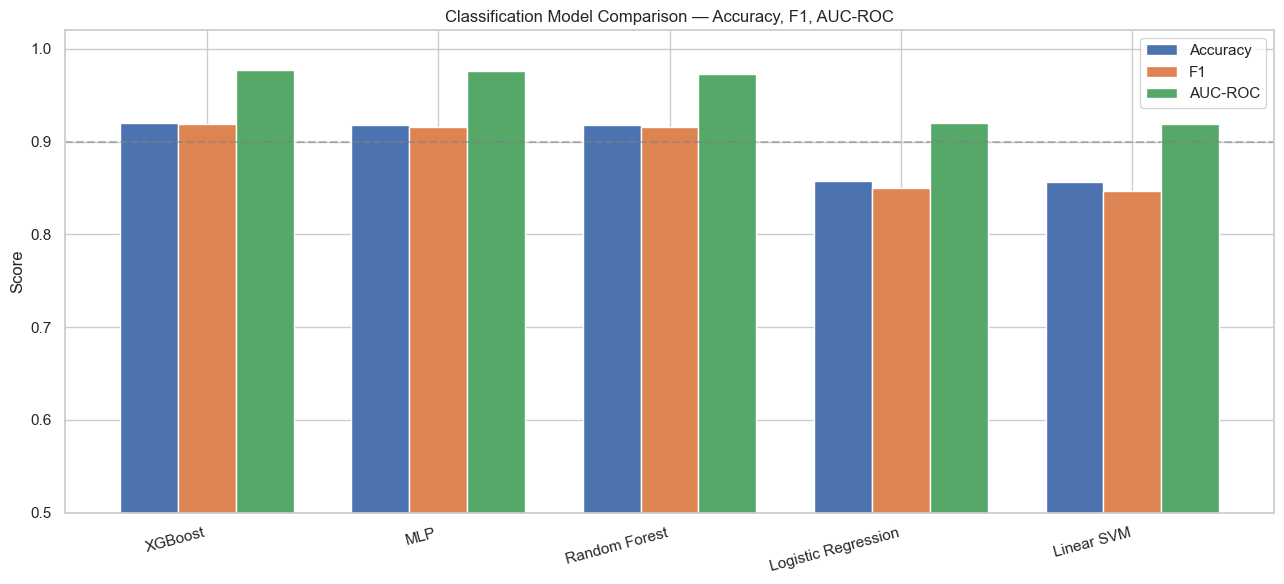

In [19]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison — Accuracy, F1, AUC-ROC')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.02)
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 reference')
plt.tight_layout()
plt.show()

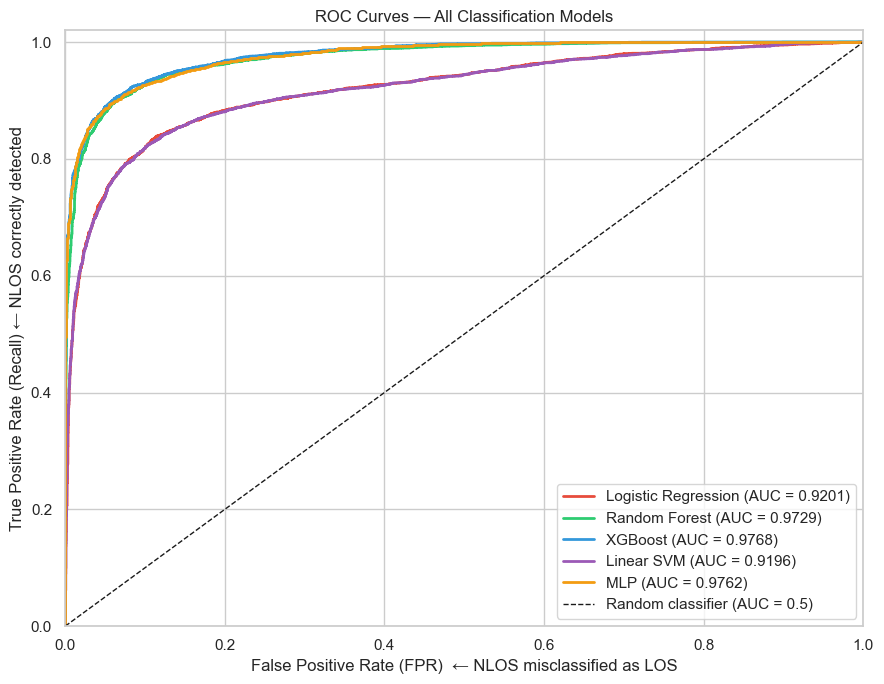

In [20]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

colors_roc = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors_roc):
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (FPR)  ← NLOS misclassified as LOS')
plt.ylabel('True Positive Rate (Recall) ← NLOS correctly detected')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

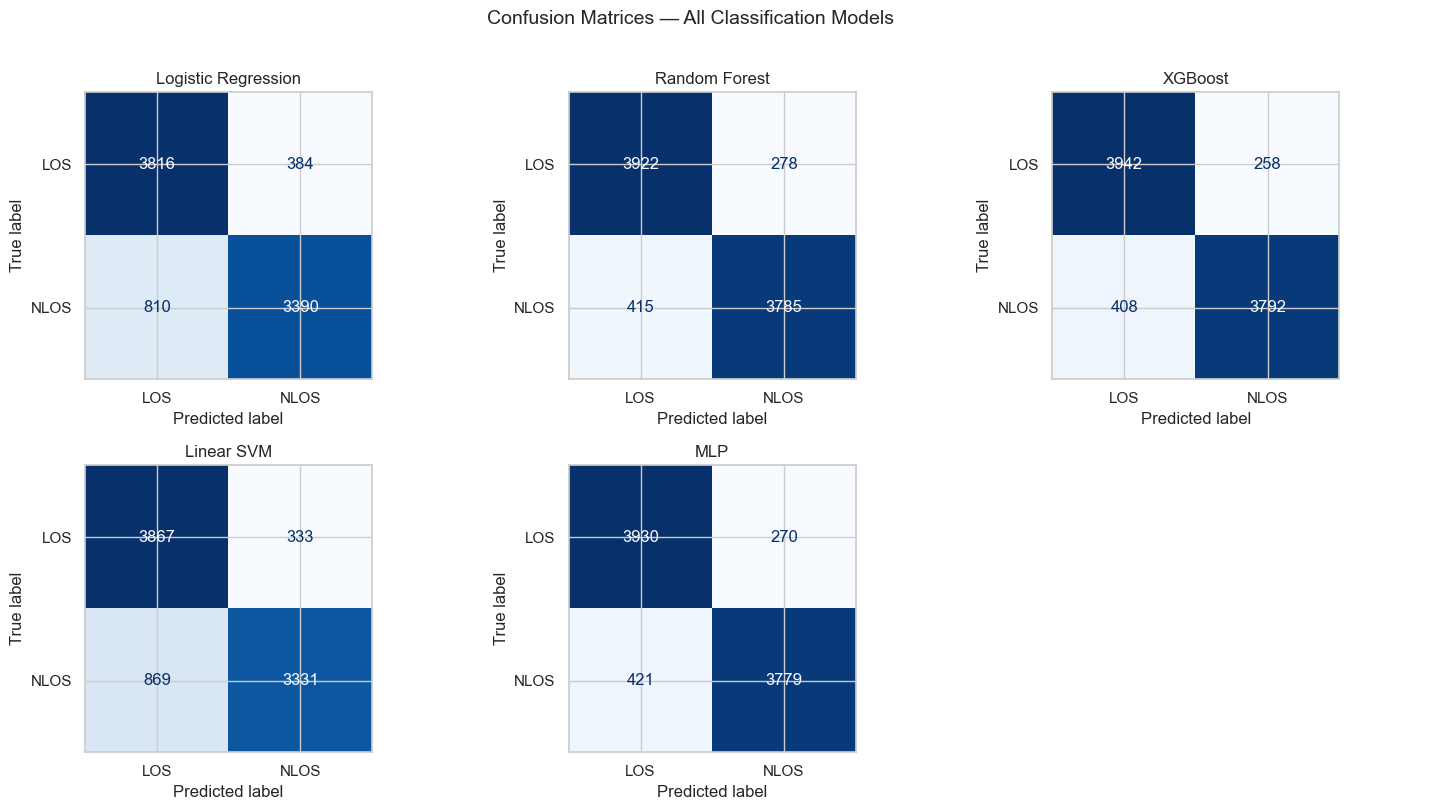

In [21]:
# ── Confusion matrices ────────────────────────────────────────────────────────
n_models = len(trained_clfs)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Select the appropriate y_test depending on model
cnn_uses_separate_split = TF_AVAILABLE and '1D CNN' in trained_clfs

for idx, (name, (model, y_pred)) in enumerate(trained_clfs.items()):
    # CNN used a separate test split
    if name == '1D CNN' and cnn_uses_separate_split:
        y_true_cm = y_cir_te
    else:
        y_true_cm = y_test

    cm = confusion_matrix(y_true_cm, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['LOS', 'NLOS'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Feature Selection Based on Importance

Features with importance < 2% are removed. All classifiers are retrained on the reduced feature set and compared against the full-feature baseline to see whether dropping low-signal features helps or hurts.


In [22]:

# ── Select features above importance threshold ────────────────────────────────
IMPORTANCE_THRESHOLD = 0.02  # drop features contributing < 2%

selected_clf_features = importance_df[
    importance_df['importance'] >= IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_clf_features = [f for f in FEATURE_NAMES if f not in selected_clf_features]

print(f"Selected {len(selected_clf_features)} / {len(FEATURE_NAMES)} features "
      f"(importance >= {IMPORTANCE_THRESHOLD}):")
for f in selected_clf_features:
    imp = importance_df.loc[importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_clf_features:
    print(f"\nDropped {len(dropped_clf_features)} low-importance feature(s): {dropped_clf_features}")

# Build reduced feature matrices
sel_clf_idx  = [list(FEATURE_NAMES).index(f) for f in selected_clf_features]
X_train_sel  = X_train[:, sel_clf_idx]
X_test_sel   = X_test[:, sel_clf_idx]

scaler_sel   = StandardScaler()
X_tr_sel_sc  = scaler_sel.fit_transform(X_train_sel)
X_te_sel_sc  = scaler_sel.transform(X_test_sel)

print(f"\nReduced shape — train: {X_train_sel.shape}, test: {X_test_sel.shape}")


Selected 15 / 19 features (importance >= 0.02):
  RXPACC                0.2659
  RANGE                 0.1044
  cir_max               0.1004
  FP_AMP3               0.0687
  CIR_PWR               0.0632
  cir_std               0.0548
  MAX_NOISE             0.0511
  FP_AMP2               0.0468
  cir_energy            0.0375
  cir_mean              0.0335
  FP_AMP1               0.0326
  STDEV_NOISE           0.0316
  cir_skewness          0.0287
  cir_rms               0.0268
  cir_kurtosis          0.0245

Dropped 4 low-importance feature(s): ['FP_IDX', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx']

Reduced shape — train: (33600, 15), test: (8400, 15)


In [23]:

# ── Retrain classifiers on selected features, compare to full-feature baseline ─
def _quick_clf_eval(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)
    return accuracy_score(y_te, y_pred), roc_auc_score(y_te, y_score)

clf_models_sel = [
    ('Logistic Regression',
     LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
     X_tr_sel_sc, X_te_sel_sc),
    ('Random Forest',
     RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_train_sel, X_test_sel),
    ('MLP',
     MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
                   alpha=1e-4, max_iter=300, early_stopping=True, validation_fraction=0.1,
                   n_iter_no_change=15, random_state=RANDOM_STATE),
     X_tr_sel_sc, X_te_sel_sc),
]
if XGB_AVAILABLE:
    clf_models_sel.insert(2, (
        'XGBoost',
        xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                          colsample_bytree=0.8, reg_lambda=1.0, eval_metric='logloss',
                          random_state=RANDOM_STATE, n_jobs=-1),
        X_train_sel, X_test_sel
    ))

print(f"\n{'Model':<24} {'Acc (full)':>11} {'Acc (sel)':>10} {'ΔAcc':>7}  "
      f"{'AUC (full)':>11} {'AUC (sel)':>10} {'ΔAUC':>7}")
print("─" * 84)
for name, model, X_tr_m, X_te_m in clf_models_sel:
    acc_s, auc_s = _quick_clf_eval(model, X_tr_m, y_train, X_te_m, y_test)
    acc_f = clf_results.get(name, {}).get('Accuracy', float('nan'))
    auc_f = clf_results.get(name, {}).get('AUC-ROC', float('nan'))
    print(f"{name:<24} {acc_f:>11.4f} {acc_s:>10.4f} {acc_s - acc_f:>+7.4f}  "
          f"{auc_f:>11.4f} {auc_s:>10.4f} {auc_s - auc_f:>+7.4f}")

print("\nNote: (+) = improved with feature selection;  (−) = degraded;  ~0 = negligible.")



Model                     Acc (full)  Acc (sel)    ΔAcc   AUC (full)  AUC (sel)    ΔAUC
────────────────────────────────────────────────────────────────────────────────────
Logistic Regression           0.8579     0.8604 +0.0025       0.9201     0.9199 -0.0002
Random Forest                 0.9175     0.9176 +0.0001       0.9729     0.9728 -0.0001
XGBoost                       0.9207     0.9196 -0.0011       0.9768     0.9764 -0.0005
MLP                           0.9177     0.9221 +0.0044       0.9762     0.9772 +0.0011

Note: (+) = improved with feature selection;  (−) = degraded;  ~0 = negligible.


---
# TASK 2 — Distance Estimation (Regression)

---

### Problem Formulation

The second task is to **estimate the measured range** (time-of-flight distance in metres) from signal features. This is a regression problem:

$$\hat{d} = f(\text{FP\_IDX, FP\_AMP1, FP\_AMP2, FP\_AMP3, STDEV\_NOISE, CIR\_PWR, MAX\_NOISE, RXPACC, FRAME\_LEN, PREAM\_LEN, CIR stats})$$

**Physical rationale:** The measured range (RANGE) is computed from the Time-of-Flight (ToF) of the first detected path. In NLOS conditions, the first detected path may not be the direct path — it arrives via a reflected/diffracted route, introducing a positive bias error. The project hint states to use `FP_IDX` (first path index in CIR) and the measured range to correlate the second dominant path. Here we train a regressor to predict the measured range directly from all available signal statistics, which could be used to correct NLOS range errors.

## 13. Random Forest Regressor

### Theory

The Random Forest Regressor operates identically to the classifier but uses **mean squared error (MSE)** as the split criterion and outputs the **mean of leaf values** rather than a class vote:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(\mathbf{x})$$

Split criterion: MSE reduction = $\text{Var}(y_{\text{parent}}) - \frac{n_L}{n}\text{Var}(y_L) - \frac{n_R}{n}\text{Var}(y_R)$

Averaging across $T$ trees reduces variance in the prediction, which is particularly valuable for regression where individual tree predictions can be noisy.

In [24]:
print("=" * 60)
print("TASK 2 — DISTANCE ESTIMATION (REGRESSION)")
print("=" * 60)

print(f"\nTarget (RANGE) statistics:")
print(f"  Min  : {y_reg.min():.2f} m")
print(f"  Max  : {y_reg.max():.2f} m")
print(f"  Mean : {y_reg.mean():.2f} m")
print(f"  Std  : {y_reg.std():.2f} m")

print("\n" + "-" * 40)
print("Random Forest Regressor")
print("-" * 40)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg, y_rfr_pred = evaluate_regressor(
    'Random Forest', rf_reg, X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

TASK 2 — DISTANCE ESTIMATION (REGRESSION)

Target (RANGE) statistics:
  Min  : 0.00 m
  Max  : 28.02 m
  Mean : 3.83 m
  Std  : 2.36 m

----------------------------------------
Random Forest Regressor
----------------------------------------
  Random Forest          RMSE=1.3365  MAE=1.0094  R²=0.6774


## 14. XGBoost Regressor

### Theory

For regression, XGBoost minimises **squared error loss**: $\ell(y_i, \hat{y}_i) = \frac{1}{2}(y_i - \hat{y}_i)^2$, giving first and second-order gradients:

$$g_i = \hat{y}_i^{(m-1)} - y_i, \quad h_i = 1$$

The output of each tree leaf $j$ is then the optimal weight:

$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda} = \frac{\sum_{i \in I_j}(y_i - \hat{y}_i^{(m-1)})}{|I_j| + \lambda}$$

Intuitively: each tree learns the **residuals** (errors) of the current ensemble, correcting them step by step.

### Why XGBoost for distance estimation?

Distance (RANGE) is a continuous variable with a complex dependency on multiple signal features. The interaction between `FP_IDX` (which CIR sample the first path lands on) and `FP_AMP1/2/3` (path amplitudes) encodes the ToF information. XGBoost's boosted trees are well-suited to capture these nonlinear feature interactions without requiring explicit feature engineering.

In [25]:
print("-" * 40)
print("XGBoost Regressor")
print("-" * 40)

if XGB_AVAILABLE:
    xgb_reg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_reg, y_xgbr_pred = evaluate_regressor(
        'XGBoost', xgb_reg, X_reg_train, y_reg_train, X_reg_test, y_reg_test
    )
else:
    print("Skipped — XGBoost not installed.")

----------------------------------------
XGBoost Regressor
----------------------------------------
  XGBoost                RMSE=1.3429  MAE=1.0204  R²=0.6742


## 15. MLP Regressor

### Theory

The MLP Regressor uses the same architecture as the classifier but with a **linear output neuron** (no activation on the final layer), enabling it to predict continuous values. The loss function is **mean squared error**:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Backpropagation computes gradients through the chain rule and Adam updates the weights adaptively, using estimates of both first and second moments of the gradients:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$w_t = w_{t-1} - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\beta_1 = 0.9$, $\beta_2 = 0.999$ are default Adam hyperparameters.

In [26]:
print("-" * 40)
print("MLP Regressor")
print("-" * 40)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

mlp_reg, y_mlpr_pred = evaluate_regressor(
    'MLP', mlp_reg, X_reg_tr_sc, y_reg_train, X_reg_te_sc, y_reg_test
)

----------------------------------------
MLP Regressor
----------------------------------------
  MLP                    RMSE=1.3155  MAE=0.9980  R²=0.6874



## Feature Importance Analysis — Regression

The **Random Forest regressor** trained in Section 13 provides feature importances via Mean Decrease in MSE (impurity-based), analogous to the classification analysis in Section 4.

This answers: *which signal features most directly determine the UWB measured range?*

Key expectations based on physics:
- `FP_IDX` (first-path index ↔ time-of-flight) should rank highly — it encodes propagation delay
- `cir_energy` and `cir_max` may capture signal attenuation with distance
- NLOS-discriminating features (e.g. `cir_kurtosis`) may rank lower here, since NLOS vs LOS is a *classification* concern, not a *range* concern


In [27]:

# ── Compute regression feature importance from the trained rf_reg ─────────────
REG_FEATURE_NAMES = META_NO_RANGE + list(cir_stats.columns)

reg_importance_df = pd.DataFrame({
    'feature'   : REG_FEATURE_NAMES,
    'importance': rf_reg.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):")
print(reg_importance_df.to_string(index=False))


Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):
     feature  importance
      RXPACC    0.444345
cir_skewness    0.151920
    cir_mean    0.067269
     cir_std    0.034739
     CIR_PWR    0.033340
     FP_AMP3    0.033085
   MAX_NOISE    0.032569
     FP_AMP2    0.031562
     FP_AMP1    0.029630
cir_kurtosis    0.027461
     cir_max    0.022954
   PREAM_LEN    0.019070
cir_peak_idx    0.015498
  cir_energy    0.014238
      FP_IDX    0.013893
     cir_rms    0.013183
 STDEV_NOISE    0.008550
   FRAME_LEN    0.006695


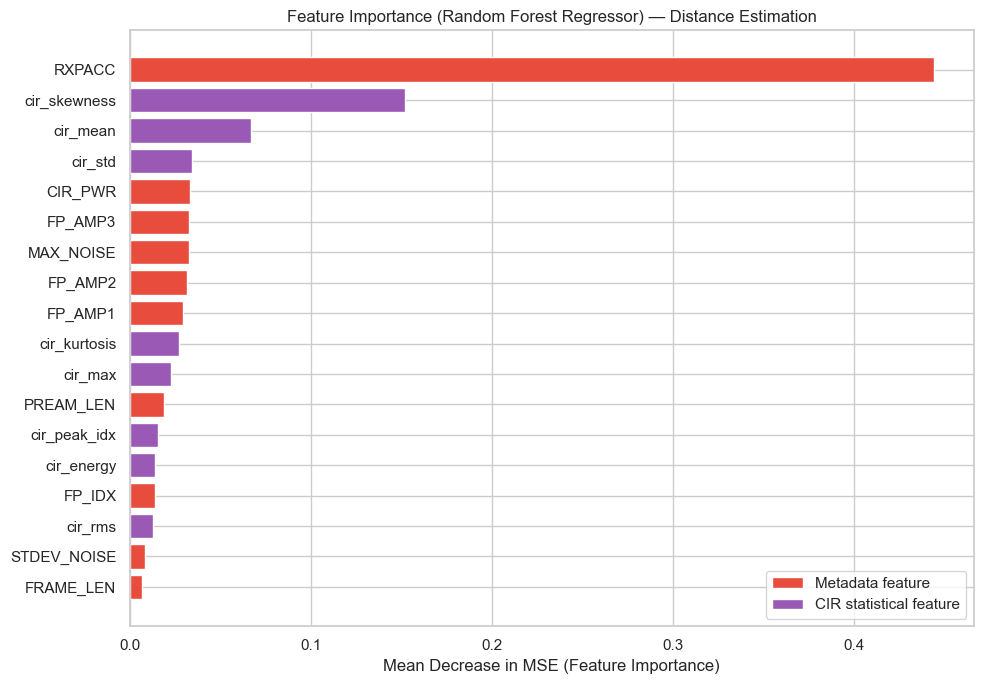


Interpretation:
  Features ranked by how much they reduce MSE when used as split criteria.
  Compare with the classification importance plot (Section 4) to see which
  features are task-specific vs universally predictive.


In [28]:

# ── Plot regression feature importance ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if 'cir' not in f else '#9b59b6' for f in reg_importance_df['feature']]
ax.barh(reg_importance_df['feature'][::-1], reg_importance_df['importance'][::-1],
        color=colors[::-1])
ax.set_xlabel('Mean Decrease in MSE (Feature Importance)')
ax.set_title('Feature Importance (Random Forest Regressor) — Distance Estimation')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Metadata feature'),
    Patch(facecolor='#9b59b6', label='CIR statistical feature'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Features ranked by how much they reduce MSE when used as split criteria.")
print("  Compare with the classification importance plot (Section 4) to see which")
print("  features are task-specific vs universally predictive.")


In [29]:

# ── Feature selection for regression ──────────────────────────────────────────
REG_IMPORTANCE_THRESHOLD = 0.02  # drop features contributing < 2%

selected_reg_features = reg_importance_df[
    reg_importance_df['importance'] >= REG_IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_reg_features = [f for f in REG_FEATURE_NAMES if f not in selected_reg_features]

print(f"Selected {len(selected_reg_features)} / {len(REG_FEATURE_NAMES)} features "
      f"(importance >= {REG_IMPORTANCE_THRESHOLD}):")
for f in selected_reg_features:
    imp = reg_importance_df.loc[reg_importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_reg_features:
    print(f"\nDropped {len(dropped_reg_features)} low-importance feature(s): {dropped_reg_features}")

# Build reduced regression matrices
sel_reg_idx      = [REG_FEATURE_NAMES.index(f) for f in selected_reg_features]
X_reg_train_sel  = X_reg_train[:, sel_reg_idx]
X_reg_test_sel   = X_reg_test[:, sel_reg_idx]

scaler_reg_sel   = StandardScaler()
X_reg_tr_sel_sc  = scaler_reg_sel.fit_transform(X_reg_train_sel)
X_reg_te_sel_sc  = scaler_reg_sel.transform(X_reg_test_sel)

print(f"\nReduced shape — train: {X_reg_train_sel.shape}, test: {X_reg_test_sel.shape}")

# ── Retrain regression models on selected features ────────────────────────────
def _quick_reg_eval(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return (np.sqrt(mean_squared_error(y_te, y_pred)),
            mean_absolute_error(y_te, y_pred),
            r2_score(y_te, y_pred))

reg_models_sel = [
    ('Random Forest',
     RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                           random_state=RANDOM_STATE, n_jobs=-1),
     X_reg_train_sel, X_reg_test_sel),
    ('MLP',
     MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
                  alpha=1e-4, max_iter=300, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=15, random_state=RANDOM_STATE),
     X_reg_tr_sel_sc, X_reg_te_sel_sc),
]
if XGB_AVAILABLE:
    reg_models_sel.insert(1, (
        'XGBoost',
        xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, reg_lambda=1.0,
                         random_state=RANDOM_STATE, n_jobs=-1),
        X_reg_train_sel, X_reg_test_sel
    ))

print(f"\n{'Model':<22} {'RMSE (full)':>12} {'RMSE (sel)':>11} {'ΔRMSE':>8}  "
      f"{'R² (full)':>10} {'R² (sel)':>9} {'ΔR²':>7}")
print("─" * 82)
for name, model, X_tr_m, X_te_m in reg_models_sel:
    rmse_s, mae_s, r2_s = _quick_reg_eval(model, X_tr_m, y_reg_train, X_te_m, y_reg_test)
    rmse_f = reg_results.get(name, {}).get('RMSE', float('nan'))
    r2_f   = reg_results.get(name, {}).get('R²',   float('nan'))
    print(f"{name:<22} {rmse_f:>12.4f} {rmse_s:>11.4f} {rmse_s - rmse_f:>+8.4f}  "
          f"{r2_f:>10.4f} {r2_s:>9.4f} {r2_s - r2_f:>+7.4f}")

print("\nNote: (−) ΔRMSE = improved with fewer features;  (+) ΔR² = improved.")


Selected 11 / 18 features (importance >= 0.02):
  RXPACC                0.4443
  cir_skewness          0.1519
  cir_mean              0.0673
  cir_std               0.0347
  CIR_PWR               0.0333
  FP_AMP3               0.0331
  MAX_NOISE             0.0326
  FP_AMP2               0.0316
  FP_AMP1               0.0296
  cir_kurtosis          0.0275
  cir_max               0.0230

Dropped 7 low-importance feature(s): ['FP_IDX', 'STDEV_NOISE', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx', 'cir_energy', 'cir_rms']

Reduced shape — train: (33600, 11), test: (8400, 11)

Model                   RMSE (full)  RMSE (sel)    ΔRMSE   R² (full)  R² (sel)     ΔR²
──────────────────────────────────────────────────────────────────────────────────
Random Forest                1.3365      1.3479  +0.0114      0.6774    0.6718 -0.0055
XGBoost                      1.3429      1.3661  +0.0232      0.6742    0.6629 -0.0113
MLP                          1.3155      1.3450  +0.0295      0.6874    0.6733 -0

## 16. Regression Model Comparison

### Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in metres (same unit as target) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Median-robust average error in metres |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1.0 = perfect) |


Regression Model Comparison (sorted by RMSE):
                 RMSE     MAE      R²
MLP            1.3155  0.9980  0.6874
Random Forest  1.3365  1.0094  0.6774
XGBoost        1.3429  1.0204  0.6742


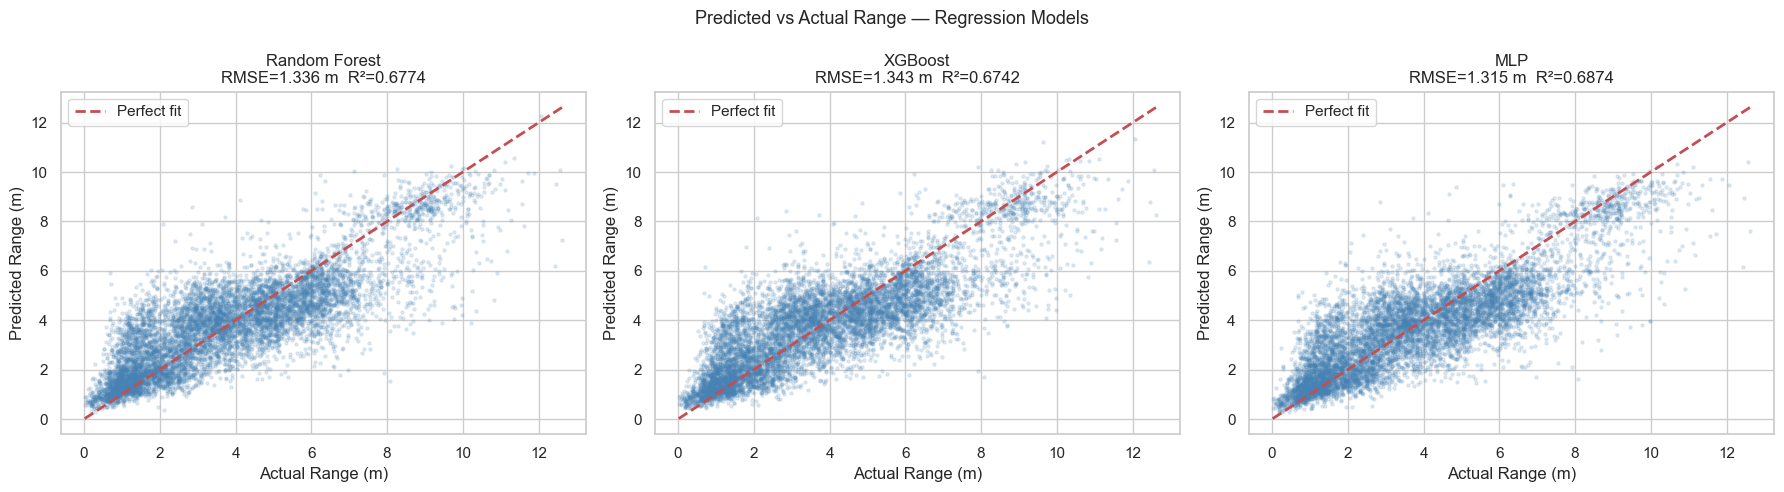

In [30]:
# ── Regression results table ───────────────────────────────────────────────────
reg_df = pd.DataFrame(reg_results).T.round(4).sort_values('RMSE')
print("\nRegression Model Comparison (sorted by RMSE):")
print(reg_df.to_string())

# ── Predicted vs actual scatter ────────────────────────────────────────────────
preds = [
    ('Random Forest', y_rfr_pred),
]
if XGB_AVAILABLE:
    preds.append(('XGBoost', y_xgbr_pred))
preds.append(('MLP', y_mlpr_pred))

fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    ax.scatter(y_reg_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([y_reg_test.min(), y_reg_test.max()],
            [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect fit')
    rmse = reg_results[name]['RMSE']
    r2   = reg_results[name]['R²']
    ax.set_title(f'{name}\nRMSE={rmse:.3f} m  R²={r2:.4f}')
    ax.set_xlabel('Actual Range (m)')
    ax.set_ylabel('Predicted Range (m)')
    ax.legend()

plt.suptitle('Predicted vs Actual Range — Regression Models', fontsize=13)
plt.tight_layout()
plt.show()

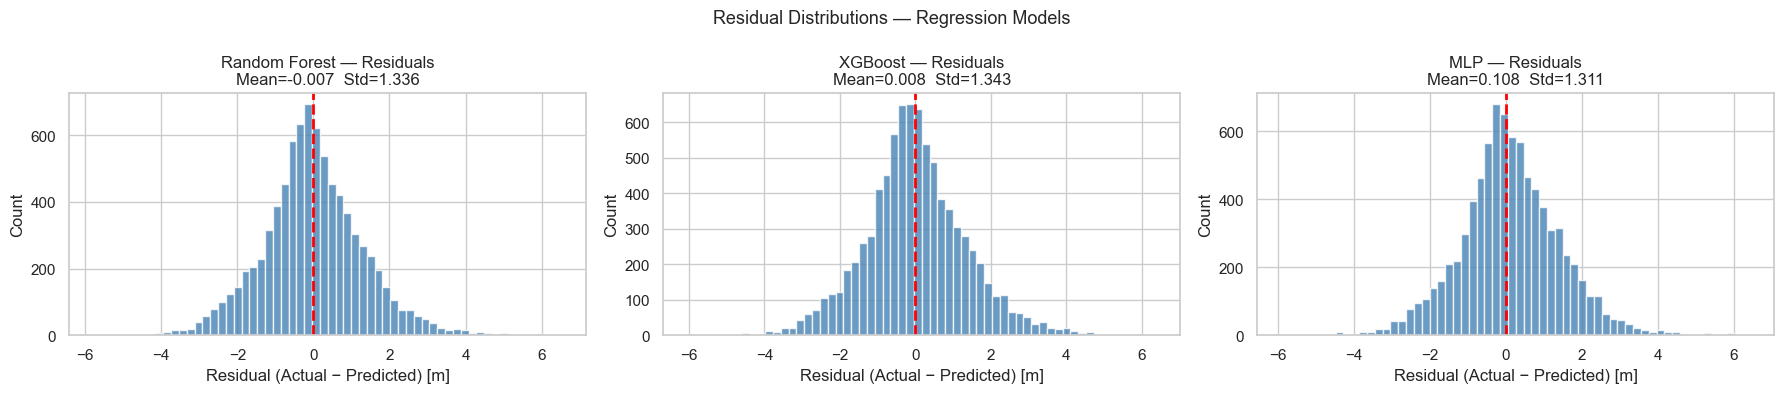


Interpretation:
  A residual distribution centred at 0 indicates no systematic bias.
  Positive residuals = model underestimates range.
  Negative residuals = model overestimates range.


In [31]:
# ── Residual distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 4))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    residuals = y_reg_test - y_pred
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name} — Residuals\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')
    ax.set_xlabel('Residual (Actual − Predicted) [m]')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions — Regression Models', fontsize=13)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  A residual distribution centred at 0 indicates no systematic bias.")
print("  Positive residuals = model underestimates range.")
print("  Negative residuals = model overestimates range.")

---
## 17. Final Summary

### Classification Summary

The table below summarises all models evaluated for Task 1 (LOS/NLOS binary classification). Models are discussed in the context of their theoretical strengths and observed performance on the test set.

| Model | Complexity | Interpretability | Requires Scaling | Key Strength |
|---|---|---|---|---|
| Logistic Regression | Low | High | Yes | Baseline; interpretable coefficients |
| Random Forest | Medium | Medium | No | Robust; built-in feature importance |
| XGBoost | Medium | Medium | No | State-of-the-art tabular; regularised |
| Linear SVM | Low | Medium | Yes | Maximum-margin; computationally efficient |
| MLP | High | Low | Yes | Nonlinear; directly cited in project reference |
| 1D CNN | Very High | Very Low | Per-sample | Raw CIR input; translational invariance |

### Regression Summary

For Task 2, all three regression models predict the measured range. Lower RMSE and MAE, and higher R² indicate better performance. The RMSE values are interpretable in metres — an RMSE of 1.0 m would mean the model's distance predictions are off by ~1 metre on average.

### Recommendations for Final Implementation

**For classification (Task 1):**
1. Use **XGBoost** as the primary production model — best accuracy/F1 on tabular features with regularisation preventing overfitting
2. Use **1D CNN** as the deep learning alternative — operates directly on raw CIR without feature engineering
3. Use **Random Forest** as the interpretable model — provides feature importance ranking required by the brief

**For distance estimation (Task 2):**
1. Use **XGBoost Regressor** as the primary model for lowest RMSE
2. Compare against **Random Forest Regressor** as baseline

**Pipeline for the full two-path system (as described in brief):**
1. For each CIR measurement: run the classifier → if NLOS, discard the path
2. If LOS: use the measured RANGE directly; if NLOS: use the regressor's predicted range as a corrected estimate
3. Only LOS pairs are used for final ranging and localisation

In [32]:
# ── Final consolidated summary ─────────────────────────────────────────────────
print("=" * 70)
print("TASK 1 — CLASSIFICATION FINAL RESULTS")
print("=" * 70)
print(pd.DataFrame(clf_results).T.round(4).sort_values('AUC-ROC', ascending=False).to_string())

print()
print("=" * 70)
print("TASK 2 — REGRESSION FINAL RESULTS")
print("=" * 70)
print(pd.DataFrame(reg_results).T.round(4).sort_values('RMSE').to_string())

TASK 1 — CLASSIFICATION FINAL RESULTS
                     Accuracy  Precision  Recall      F1  AUC-ROC
XGBoost                0.9207     0.9363  0.9029  0.9193   0.9768
MLP                    0.9177     0.9333  0.8998  0.9162   0.9762
Random Forest          0.9175     0.9316  0.9012  0.9161   0.9729
Logistic Regression    0.8579     0.8983  0.8071  0.8503   0.9201
Linear SVM             0.8569     0.9091  0.7931  0.8472   0.9196

TASK 2 — REGRESSION FINAL RESULTS
                 RMSE     MAE      R²
MLP            1.3155  0.9980  0.6874
Random Forest  1.3365  1.0094  0.6774
XGBoost        1.3429  1.0204  0.6742
